In [3]:
import pandas as pd
import os
import torch
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
import random
from IPython.display import Audio, display
import matplotlib.pyplot as plt
import numpy as np

### Load and inspect CSV files

In [4]:
ROOT = "data"
GT   = os.path.join(ROOT, "FSD50K.ground_truth")

dev_csv  = pd.read_csv(os.path.join(GT, "dev.csv"))
eval_csv = pd.read_csv(os.path.join(GT, "eval.csv"))
vocab    = pd.read_csv(os.path.join(GT, "vocabulary.csv"), header=None, names=["index", "label_name", "mid"])

print("=== dev.csv ===")
print(dev_csv.head())
print(dev_csv.shape)
print(dev_csv["split"].value_counts())

print("\n=== eval.csv ===")
print(eval_csv.head())

print("\n=== vocabulary.csv ===")
print(vocab.head(10))

=== dev.csv ===
   fname                                             labels  \
0  64760  Electric_guitar,Guitar,Plucked_string_instrume...   
1  16399  Electric_guitar,Guitar,Plucked_string_instrume...   
2  16401  Electric_guitar,Guitar,Plucked_string_instrume...   
3  16402  Electric_guitar,Guitar,Plucked_string_instrume...   
4  16404  Electric_guitar,Guitar,Plucked_string_instrume...   

                                            mids  split  
0  /m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf  train  
1  /m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf  train  
2  /m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf  train  
3  /m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf  train  
4  /m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf  train  
(40966, 4)
split
train    36796
val       4170
Name: count, dtype: int64

=== eval.csv ===
    fname                                             labels  \
0   37199  Electric_guitar,Guitar,Plucked_string_instrume...   
1  175151  Electric_guitar,Guitar,Pluc

In [5]:
print(dev_csv["labels"].iloc[0])

Electric_guitar,Guitar,Plucked_string_instrument,Musical_instrument,Music


### Look at the first audio file

In [6]:
wav_path = "data/FSD50K.dev_audio/64760.wav"

waveform, sample_rate = torchaudio.load(wav_path)

print(f"Sample rate : {sample_rate}")
print(f"Waveform shape : {waveform.shape}")
print(f"Duration : {waveform.shape[1] / sample_rate:.2f} seconds")
print(f"Min value : {waveform.min():.4f}")
print(f"Max value : {waveform.max():.4f}")

Sample rate : 44100
Waveform shape : torch.Size([1, 75601])
Duration : 1.71 seconds
Min value : -0.4236
Max value : 0.4032


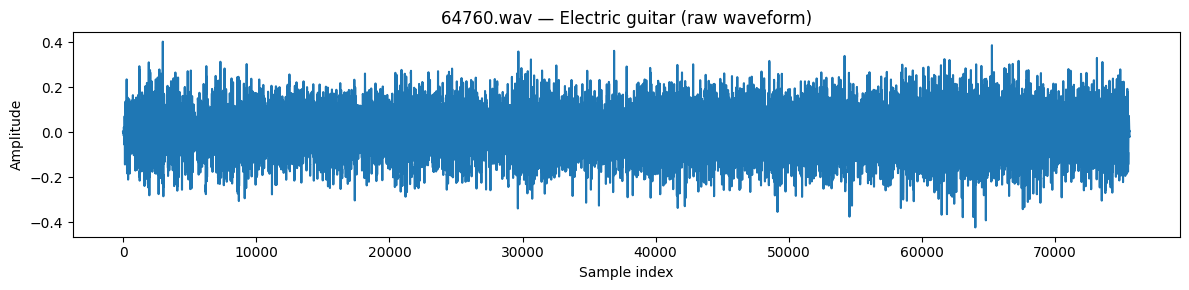

In [7]:
plt.figure(figsize=(12, 3))
plt.plot(waveform[0].numpy())   # [0] because shape is (1, samples) — we grab the one channel
plt.title("64760.wav — Electric guitar (raw waveform)")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

### Transform first sample to mel spectrogram and visualize 

c:\Users\AnneG\miniconda3\envs\appmlenv\Lib\site-packages\torchaudio\functional\functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


Mel spectrogram shape: torch.Size([1, 128, 148])


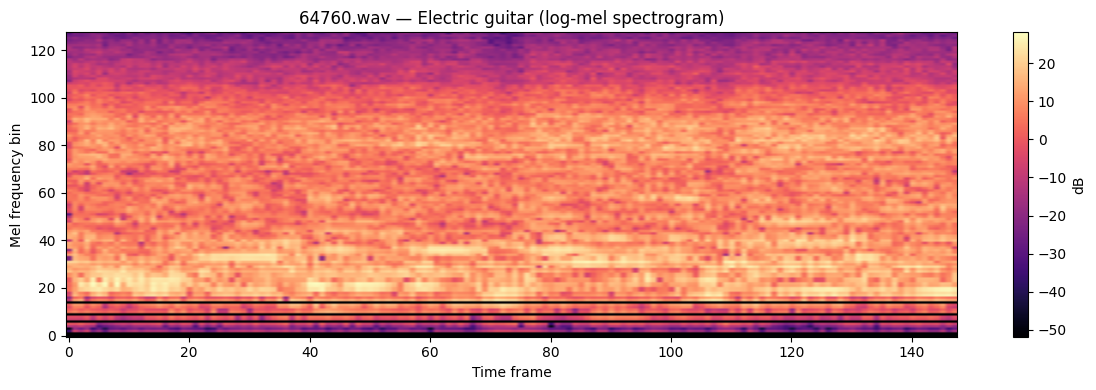

In [8]:
mel_transform = T.MelSpectrogram(
    sample_rate = 44100,
    n_fft       = 1024,   # window size for the frequency analysis
    hop_length  = 512,    # how many samples to step between windows
    n_mels      = 128,    # number of frequency bins
    f_max       = 8000,   # only look at frequencies up to 8000 Hz
)
amplitude_to_db = T.AmplitudeToDB(top_db=80)

mel         = mel_transform(waveform)       # (1, 128, time_frames)
mel_db      = amplitude_to_db(mel)          # convert to decibels — easier to visualise

print(f"Mel spectrogram shape: {mel_db.shape}")

plt.figure(figsize=(12, 4))
plt.imshow(mel_db[0].numpy(), origin="lower", aspect="auto", cmap="magma")
plt.title("64760.wav — Electric guitar (log-mel spectrogram)")
plt.xlabel("Time frame")
plt.ylabel("Mel frequency bin")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show();

In [9]:
#Create a function that plots a spectrogram for later use
def plot_spectrogram(mel_db, fname):
    plt.figure(figsize=(12, 4))
    plt.imshow(mel_db[0].numpy(), origin="lower", aspect="auto", cmap="magma")
    title="Log-Mel Spectrogram for file: "+fname
    plt.title(title)
    plt.xlabel("Time frame")
    plt.ylabel("Mel frequency bin")
    plt.colorbar(label="dB")
    plt.tight_layout()
    plt.show()

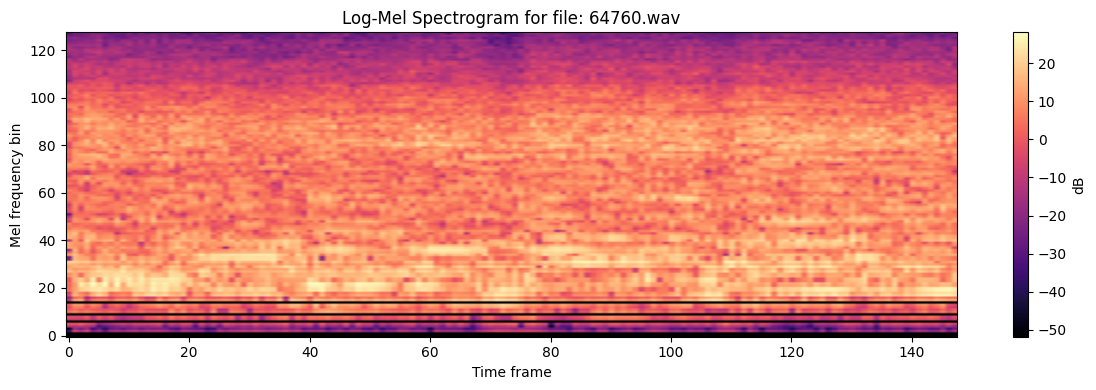

In [10]:
#test function with the same file as before
plot_spectrogram(mel_db, "64760.wav")



### Fix it such that instead of a list of comma-separated labels, it is a 200-dim tensor with entry 0 or 1

In [11]:
print(vocab.columns.tolist())
print(vocab.head())

['index', 'label_name', 'mid']
   index                          label_name         mid
0      0  Accelerating_and_revving_and_vroom  /m/07q2z82
1      1                           Accordion     /m/0mkg
2      2                     Acoustic_guitar  /m/042v_gx
3      3                            Aircraft     /m/0k5j
4      4                               Alarm  /m/07pp_mv


In [12]:
# Build a dictionary: class name → integer index
label_to_idx = {row["label_name"]: row["index"] for _, row in vocab.iterrows()}

# Sanity check
print(label_to_idx["Electric_guitar"])
print(label_to_idx["Bark"])
print(f"Total classes: {len(label_to_idx)}")

69
7
Total classes: 200


In [13]:
NUM_CLASSES = len(label_to_idx)  # 200

def encode_labels(label_string):
    vec = torch.zeros(NUM_CLASSES, dtype=torch.float32)
    for lbl in label_string.split(","):
        vec[label_to_idx[lbl]] = 1.0
    return vec

# Test it
result = encode_labels("Electric_guitar,Guitar,Music")
print(result.shape)              # torch.Size([200])
print(result.sum())              # tensor(3.)  — 3 active labels
print(result.nonzero())          # shows which indices are 1.0

torch.Size([200])
tensor(3.)
tensor([[ 69],
        [ 90],
        [120]])


### Create dataset class for Pytorch such that calling an index in the data set returns the log mel spectrogram and the 200-dimensional tensor for a specific file (corresponding to that index)

In [14]:
SAMPLE_RATE = 44100
MAX_SAMPLES = SAMPLE_RATE * 10   # 441000 — exactly 10 seconds

mel_transform = T.MelSpectrogram(
    sample_rate = SAMPLE_RATE,
    n_fft       = 1024,
    hop_length  = 512,
    n_mels      = 128,
    f_max       = 8000,   # only look at frequencies up to 8000 Hz
)

amplitude_to_db = T.AmplitudeToDB(top_db=80)


class FSD50KDataset(Dataset):

    def __init__(self, df, audio_dir):
        self.df        = df.reset_index(drop=True)
        self.audio_dir = audio_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        wav_path = os.path.join(self.audio_dir, f"{row['fname']}.wav")

        # 1. Load audio
        waveform, sr = torchaudio.load(wav_path)   # (1, samples)

        # 2. Pad or truncate to exactly 10 seconds
        n = waveform.shape[1]
        if n < MAX_SAMPLES:
            # pad with zeros at the end
            waveform = torch.nn.functional.pad(waveform, (0, MAX_SAMPLES - n))
        else:
            # truncate
            waveform = waveform[:, :MAX_SAMPLES]

        # 3. Mel spectrogram
        mel    = mel_transform(waveform)      # (1, 128, time_frames)
        log_mel = amplitude_to_db(mel)        # (1, 128, time_frames)

        # 4. Convert labels to vector 
        label = encode_labels(row["labels"])  # (200,)

        return log_mel, label

c:\Users\AnneG\miniconda3\envs\appmlenv\Lib\site-packages\torchaudio\functional\functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


### Define the training data set and check size + labels

In [15]:
train_df = dev_csv[dev_csv["split"] == "train"]

train_dataset = FSD50KDataset(train_df, "data/FSD50K.dev_audio")

# Get a single sample
feature, label = train_dataset[0]
print(f"Feature shape : {feature.shape}")
print(f"Label shape   : {label.shape}")
print(f"Active labels : {label.nonzero().squeeze().tolist()}")

Feature shape : torch.Size([1, 128, 862])
Label shape   : torch.Size([200])
Active labels : [69, 90, 120, 121, 127]


In [16]:
idx_to_label = {v: k for k, v in label_to_idx.items()}
active_labels = [69, 90, 120, 121, 127]
print([idx_to_label[i] for i in active_labels]) #checking that the labels correspond to the correct classes, which we saw earlier

['Electric_guitar', 'Guitar', 'Music', 'Musical_instrument', 'Plucked_string_instrument']


In [17]:
# Make a function that turns "label" (the binary vector) into a list of active label names, for easier interpretation later
def label_names(label_vec, idx_to_label=idx_to_label):
    active_indices = label_vec.nonzero().flatten().tolist()
    names = [idx_to_label[i] for i in active_indices]
    return names

In [18]:
print(label_names(label)) #checking that the function works as intended

['Electric_guitar', 'Guitar', 'Music', 'Musical_instrument', 'Plucked_string_instrument']


### Define validation and test datasets and use DataLoader to prepare batches for NN training

In [ ]:
val_df  = dev_csv[dev_csv["split"] == "val"]
eval_df = eval_csv

val_dataset  = FSD50KDataset(val_df,  "data/FSD50K.dev_audio")
test_dataset = FSD50KDataset(eval_df, "data/FSD50K.eval_audio")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0)

In [20]:
features, labels = next(iter(train_loader))
print(f"Feature batch shape : {features.shape}")
print(f"Label batch shape   : {labels.shape}")

Feature batch shape : torch.Size([32, 1, 128, 862])
Label batch shape   : torch.Size([32, 200])


### Perform sanity checks -- Ensures that labels, spectrogram and audio makes sense together

In [21]:
def inspect_sample(dataset, idx=None):
    if idx is None:                                                 #pull random sample if no index is provided
        idx = random.randint(0, len(dataset) - 1)

    feature, label = dataset[idx]                                   #get the feature (spectrogram, mel_db) and label tensors for the sample

    row = dataset.df.iloc[idx]                                      #pull the filename by accessing the corresponding row in the dataframe
    fname = row["fname"]

    wav_path = os.path.join(dataset.audio_dir, f"{fname}.wav")      #get the path to the original audio file
    waveform, sr = torchaudio.load(wav_path)                        #load the original audio using the path name

    active = label_names(label)                                 #get the active label names 

    #Print all the relevant information about the sample: filename, active labels, listen to the audio, and plot the spectrogram

    print("Filename:", fname)

    print("Active label names:", active)

    plot_spectrogram(feature, f'{fname}')
    
    audio = Audio(waveform.squeeze().numpy(), rate=sr)
    display(audio);

    return feature, label, waveform

Filename: 340640
Active label names: ['Engine']


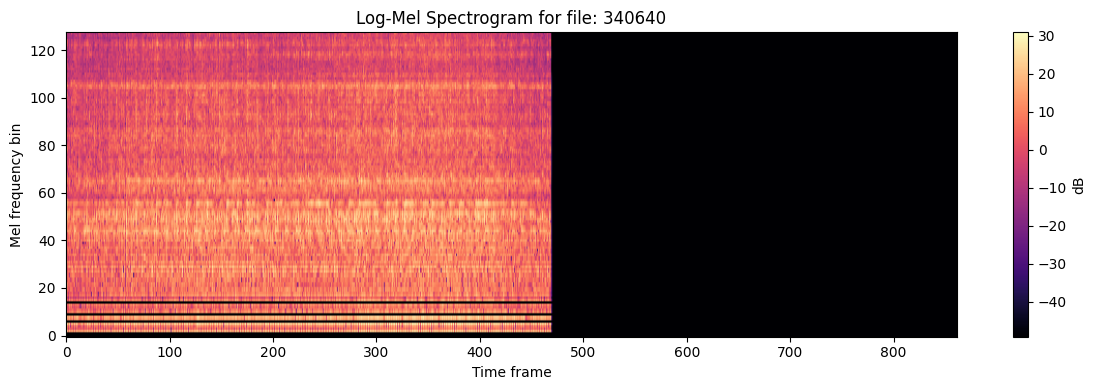

In [36]:
inspect_sample(train_dataset);

In [23]:
all_labels = (
    train_df["labels"]
    .str.split(",")
    .explode()
)

label_counts = all_labels.value_counts()

print(label_counts.head(10))

labels
Music                                      11610
Musical_instrument                         11609
Domestic_sounds_and_home_sounds             4055
Human_voice                                 3665
Animal                                      2976
Percussion                                  2731
Wind_instrument_and_woodwind_instrument     2458
Vehicle                                     2325
Bowed_string_instrument                     1841
Plucked_string_instrument                   1687
Name: count, dtype: int64


In [24]:
import json

with open("data/FSD50K.metadata/class_info_FSD50K.json") as f:
    class_info = json.load(f)

# Look at one entry
first_key = list(class_info.keys())[0]
print(f"Key format: '{first_key}'")
print(class_info[first_key])

Key format: '/m/0dv3j'
{'faq': '<div class="ui accordion">\r\n\r\n class="title">\r\n  \t<i class="dropdown icon"></i>\r\n  \tAre frying, hissing or sizzling sounds considered ‘Boiling’ sounds?\r\n\t</div>\r\n\t class="content">\r\n  \t<p>No.</p>\r\n\t</div>\r\n\r\n class="title">\r\n  \t<i class="dropdown icon"></i>\r\n  \tAre ‘Boiling’ sounds containing hissing sounds from gas stoves or kettles considered <i>Present and predominant</i> sounds?\r\n\t</div>\r\n\t class="content">\r\n  \t<p>No. When ‘Boiling’ and hissing are both salient sounds, please choose <i>Present but not predominant</i>.</p> \r\n\t</div>\r\n\r\n class="title">\r\n  \t<i class="dropdown icon"></i>\r\n  \tAre kettle whistle and pressure cooker whistle sounds considered ‘Boiling’ sounds?\r\n\t</div>\r\n\t class="content">\r\n  \t<p>No.</p>\r\n\t</div>\r\n\r\n class="title">\r\n  \t<i class="dropdown icon"></i>\r\n  \tAre bubbling sounds created by blowing water with the mouth or a straw considered ‘Boiling’ sounds?\

In [25]:
import urllib.request
import json

url = "https://raw.githubusercontent.com/audioset/ontology/master/ontology.json"
urllib.request.urlretrieve(url, "ontology.json")

with open("ontology.json") as f:
    ontology = json.load(f)

# Look at one entry
print(ontology[0])

{'id': '/m/0dgw9r', 'name': 'Human sounds', 'description': 'Sounds produced by the human body through the actions of the individual.', 'citation_uri': '', 'positive_examples': [], 'child_ids': ['/m/09l8g', '/m/01w250', '/m/09hlz4', '/m/0bpl036', '/m/0160x5', '/m/0k65p', '/m/01jg02', '/m/04xp5v', '/t/dd00012'], 'restrictions': ['abstract']}


In [26]:
# Build a lookup: mid → full entry
ontology_by_id = {entry["id"]: entry for entry in ontology}

# Build a reverse lookup: child_mid → parent_mid
child_to_parent = {}
for entry in ontology:
    for child_id in entry["child_ids"]:
        child_to_parent[child_id] = entry["id"]

# The 6 top-level family MIDs (updated to match the discovered ontology structure)
top_level = {
    "/m/0dgw9r": "Human sounds",
    "/m/0jbk":   "Animal",
    "/m/04rlf":  "Music",
    "/m/059j3w": "Natural sounds",
    "/t/dd00041": "Sounds of things",
    "/t/dd00098": "Source-ambiguous sounds",
}

def get_top_level_family(mid):
    current = mid
    while current not in top_level:
        parent = child_to_parent.get(current)
        if parent is None:
            return "Unknown"   # shouldn't happen for FSD50K classes
        current = parent
    return top_level[current]

# Test it
print(get_top_level_family("/m/02sgy"))   # Electric guitar → should be Music
print(get_top_level_family("/m/05tny_"))  # Bark → should be Animal

Music
Animal


In [27]:
# Map every class in vocabulary to its top-level family
vocab["family"] = vocab["mid"].apply(get_top_level_family)

print(vocab["family"].value_counts())
print(vocab[vocab["family"] == "Unknown"])  # should be empty

family
Sounds of things           83
Human sounds               37
Music                      34
Animal                     19
Source-ambiguous sounds    16
Natural sounds             11
Name: count, dtype: int64
Empty DataFrame
Columns: [index, label_name, mid, family]
Index: []


In [28]:
def get_clip_family(label_string):
    for lbl in label_string.split(","):
        vocab_row = vocab[vocab["label_name"] == lbl]
        if not vocab_row.empty:
            return vocab_row.iloc[0]["family"]
    return "Unknown"

dev_csv["family"] = dev_csv["labels"].apply(get_clip_family)
print(dev_csv["family"].value_counts())

family
Sounds of things           13086
Music                      12593
Human sounds                7299
Source-ambiguous sounds     3018
Animal                      2918
Natural sounds              2052
Name: count, dtype: int64


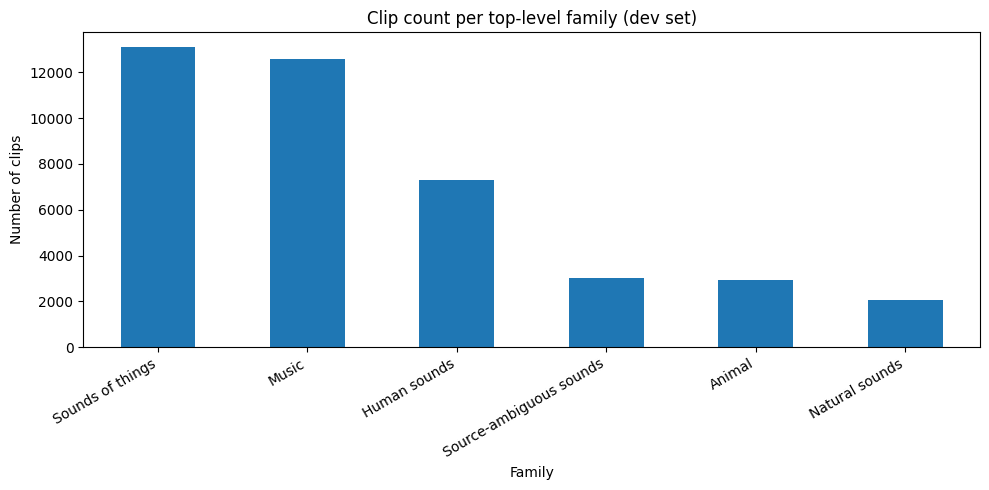

In [29]:
family_counts = dev_csv["family"].value_counts()

plt.figure(figsize=(10, 5))
family_counts.plot(kind="bar")
plt.title("Clip count per top-level family (dev set)")
plt.xlabel("Family")
plt.ylabel("Number of clips")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [30]:
train_family_counts = dev_csv[dev_csv["split"] == "train"]["family"].value_counts()
print(train_family_counts)

family
Sounds of things           11669
Music                      11476
Human sounds                6540
Animal                      2684
Source-ambiguous sounds     2567
Natural sounds              1860
Name: count, dtype: int64


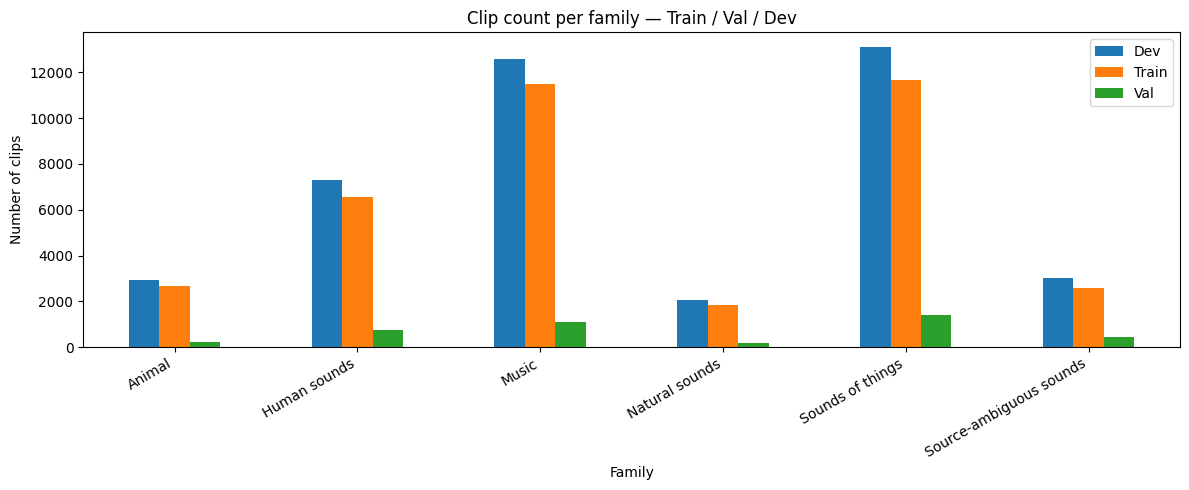

In [31]:
train_counts = dev_csv[dev_csv["split"] == "train"]["family"].value_counts()
val_counts   = dev_csv[dev_csv["split"] == "val"]["family"].value_counts()
dev_counts   = dev_csv["family"].value_counts()

# Combine into one DataFrame so families align correctly
counts_df = pd.DataFrame({
    "Dev":   dev_counts,
    "Train": train_counts,
    "Val":   val_counts,
}).fillna(0)

counts_df.plot(kind="bar", figsize=(12, 5))
plt.title("Clip count per family — Train / Val / Dev")
plt.xlabel("Family")
plt.ylabel("Number of clips")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
def get_second_level(mid):
    """Walk up the tree and return the node just below the top-level family."""
    current = mid
    visited = set()
    while True:
        parent = child_to_parent.get(current)
        if parent is None:
            return ontology_by_id[current]["name"]  # already at root
        if parent in top_level:
            return ontology_by_id[current]["name"]  # current is one below root
        if current in visited:
            return "Cycle"
        visited.add(current)
        current = parent

# Map all 200 classes to their second-level category
vocab["second_level"] = vocab["mid"].apply(get_second_level)

# Now filter to just Music and count
music_vocab = vocab[vocab["family"] == "Music"]
print(music_vocab[["label_name", "second_level"]])

                                  label_name        second_level
1                                  Accordion  Musical instrument
2                            Acoustic_guitar  Musical instrument
8                                  Bass_drum  Musical instrument
9                                Bass_guitar  Musical instrument
19                   Bowed_string_instrument  Musical instrument
20                          Brass_instrument  Musical instrument
48                              Crash_cymbal  Musical instrument
57                                    Cymbal  Musical instrument
67                                      Drum  Musical instrument
68                                  Drum_kit  Musical instrument
69                           Electric_guitar  Musical instrument
87                              Glockenspiel  Musical instrument
88                                      Gong  Musical instrument
90                                    Guitar  Musical instrument
96                       

In [33]:
# Add second_level to dev_csv
def get_clip_second_level(label_string):
    for lbl in label_string.split(","):
        vocab_row = vocab[vocab["label_name"] == lbl]
        if not vocab_row.empty:
            return vocab_row.iloc[0]["second_level"]
    return "Unknown"

dev_csv["second_level"] = dev_csv["labels"].apply(get_clip_second_level)

# Filter to Music family and count
music_clips = dev_csv[dev_csv["family"] == "Music"]
print(music_clips["second_level"].value_counts())
print(f"\nTotal music clips: {len(music_clips)}")

second_level
Musical instrument    12593
Name: count, dtype: int64

Total music clips: 12593


In [34]:
# How many clips have multiple second-level categories?
def get_all_second_levels(label_string):
    levels = set()
    for lbl in label_string.split(","):
        vocab_row = vocab[vocab["label_name"] == lbl]
        if not vocab_row.empty:
            levels.add(vocab_row.iloc[0]["second_level"])
    return levels

multi = dev_csv["labels"].apply(lambda x: len(get_all_second_levels(x)) > 1)
print(f"Clips with multiple second-level categories: {multi.sum()}")
print(dev_csv[multi]["labels"].head())

Clips with multiple second-level categories: 19273
0    Electric_guitar,Guitar,Plucked_string_instrume...
1    Electric_guitar,Guitar,Plucked_string_instrume...
2    Electric_guitar,Guitar,Plucked_string_instrume...
3    Electric_guitar,Guitar,Plucked_string_instrume...
4    Electric_guitar,Guitar,Plucked_string_instrume...
Name: labels, dtype: object


In [35]:
# Count how often each class appears across all training clips
from collections import Counter

all_labels = []
for label_string in train_df["labels"]:
    all_labels.extend(label_string.split(","))

class_counts = Counter(all_labels)

#print full class distribution sorted by count (descending) and allow python to display the full list without truncation
pd.set_option("display.max_rows", None)
print(pd.Series(class_counts).sort_values(ascending=False))
pd.reset_option("display.max_rows")

Music                                             11610
Musical_instrument                                11609
Domestic_sounds_and_home_sounds                    4055
Human_voice                                        3665
Animal                                             2976
Percussion                                         2731
Wind_instrument_and_woodwind_instrument            2458
Vehicle                                            2325
Bowed_string_instrument                            1841
Plucked_string_instrument                          1687
Guitar                                             1594
Wild_animals                                       1516
Speech                                             1321
Keyboard_(musical)                                 1242
Motor_vehicle_(road)                               1202
Water                                              1201
Alarm                                              1177
Bird                                            